# Climate Projections: Fire Weather Trends on Tribal Lands
**Series:** Tribal Fire Science & Indigenous Data Sovereignty  
**Author:** Lilly Jones, PhD  
**Last Updated:** 2025  
**Data Sources:** gridMET (historical baseline), MACAv2-METDATA (RCP 4.5/RCP 8.5 projections)

## Overview
The preceding notebooks in this series analyze fire history, capacity gaps, and
structural risk based on current and historical conditions. This notebook completes
that picture by asking: where are these conditions going?

Using MACAv2 statistically downscaled climate projections and gridMET historical
observations, we estimate how fire weather exposure is expected to change through
mid- and end-century for the ten highest fire-frequency Tribal Nations in this series.

## Fire Weather Proxy
MACAv2 provides maximum temperature and precipitation but not wind speed. This
notebook uses a fire weather proxy: days exceeding a temperature threshold with
minimal precipitation rather than the full fast-fire day index used in
`fast_fire_days_analysis.ipynb`. The proxy captures the temperature and drought
components of fire weather; the full index also requires wind.

**Proxy definition:** Annual count of months where monthly mean tmax > 95°F
AND monthly total precipitation < 10 mm.

## Climate Scenarios
| Scenario | Description |
|---|---|
| Historical (1981–2010) | gridMET observed baseline |
| RCP 4.5 | Moderate emissions reduction (stabilization ~2100) |
| RCP 8.5 | Business as usual (continued high emissions) |

## Research Questions
- Which Tribal lands face the largest projected increase in fire weather months?
- How does the divergence between RCP 4.5 and RCP 8.5 grow through the century?
- What is the difference between mid-century (2040–2069) and end-century (2070–2099)
  exposure for each Tribal Nation?

## Ensemble
Three GCMs are used: BNU-ESM, IPSL-CM5A-LR, NorESM1-M. Results show the ensemble
mean with min/max range. This is a lightweight illustrative ensemble: a full
uncertainty analysis would use all 20 MACAv2 models.

In [2]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
from datetime import datetime

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from shapely.validation import make_valid

from src.data import constants, loaders, validators
from src.data.constants import PRIMARY_TRIBES
from src.geo import utils as geo_utils
from src.indigenous.sovereignty import generate_citations, print_data_acknowledgment
from src.viz import charts, styles

styles.apply_mpl_style()
%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print(f"Repo root : {REPO_ROOT}")
print(f"Output dir: {constants.OUTPUTS_DIR}")

Repo root : C:\Users\gekek\Documents\tfs_refactor
Output dir: C:\Users\gekek\Documents\tfs_refactor\outputs


In [3]:
# Print data acknowledgment
print_data_acknowledgment(source_keys=["census_aiannh", "maca_projections"])

DATA SOVEREIGNTY ACKNOWLEDGMENT
This analysis uses data that describes Indigenous and Tribal lands,
communities, and fire histories. This project is guided by three
complementary data governance frameworks:

OCAP®: Tribal Nations own, control, access, and possess data about
  their own communities and territories.
  Reference: https://fnigc.ca/ocap-training/

CARE: Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to communities,
  and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR: Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; CARE and OCAP® govern the ethical
  obligations to Tribal Nations that FAIR alone does not address.
  Reference: https://www.go-fair.org/fair-principles/

We recognize that:

• Tribal Nations are sovereign governments with the right to control
  data about their own communities and territori

## Configuration

In [4]:
# Analysis parameters
TRIBES_OF_INTEREST = PRIMARY_TRIBES

# MACAv2 ensemble: 3 GCMs spanning the spread of projections
MODELS = ["BNU-ESM", "IPSL-CM5A-LR", "NorESM1-M"]

# Time periods
HIST_START, HIST_END      = 1981, 2010   # gridMET historical baseline
MID_START,  MID_END       = 2040, 2069   # Mid-century
END_START,  END_END       = 2070, 2099   # End-century

# Fire weather proxy is temperature only (gridMET loader does not return precip)
# A fire weather month is defined as: monthly mean tmax > threshold
# Note: full fast-fire index also requires wind and RH, this is T-only proxy
TMAX_THRESHOLD_F    = 95.0
PRECIP_THRESHOLD_MM = None  # not used: precip not available from gridMET loader

# Kelvin to Fahrenheit conversion
K_TO_F = lambda k: (k - 273.15) * 9/5 + 32

print("CLIMATE PROJECTION CONFIGURATION")
print("=" * 55)
print(f"  Tribal Nations   : {len(TRIBES_OF_INTEREST)}")
print(f"  GCM ensemble     : {', '.join(MODELS)}")
print(f"  Historical period: {HIST_START}–{HIST_END} (gridMET)")
print(f"  Mid-century      : {MID_START}–{MID_END} (MACAv2)")
print(f"  End-century      : {END_START}–{END_END} (MACAv2)")
print(f"\nFire weather proxy:")
print(f"  Monthly tmax > {TMAX_THRESHOLD_F}°F AND monthly precip < {PRECIP_THRESHOLD_MM} mm")
print(f"  Note: wind component not available in MACAv2, P not available in gridMet, proxy is T only")

CLIMATE PROJECTION CONFIGURATION
  Tribal Nations   : 10
  GCM ensemble     : BNU-ESM, IPSL-CM5A-LR, NorESM1-M
  Historical period: 1981–2010 (gridMET)
  Mid-century      : 2040–2069 (MACAv2)
  End-century      : 2070–2099 (MACAv2)

Fire weather proxy:
  Monthly tmax > 95.0°F AND monthly precip < None mm
  Note: wind component not available in MACAv2, P not available in gridMet, proxy is T only


## Load Tribal Land Boundaries and Centroids

In [5]:
# Census TIGER AIANNH 
all_tribal = loaders.load_census_aian()
all_tribal = validators.validate_geodataframe(
    all_tribal, "census_aiannh", required_columns=["geometry", "NAME"]
)
tribal_lands = all_tribal[all_tribal["NAME"].isin(TRIBES_OF_INTEREST)].copy()
tribal_lands = tribal_lands.dissolve(by="NAME", as_index=False).reset_index(drop=True)
tribal_lands["geometry"] = tribal_lands.geometry.apply(
    lambda g: make_valid(g) if g is not None else g
)
CONUS = geo_utils.bbox_geodataframe((-127, 24, -65, 50)).geometry.iloc[0]
tribal_lands = tribal_lands[
    tribal_lands.geometry.notnull() &
    tribal_lands.geometry.is_valid &
    tribal_lands.intersects(CONUS)
].copy().reset_index(drop=True)

# Project centroids for accurate position
centroids_proj = tribal_lands.to_crs("EPSG:5070").geometry.centroid
centroids_geo  = centroids_proj.to_crs(constants.CRS_GEOGRAPHIC)
tribal_lands["centroid_lon"] = centroids_geo.x
tribal_lands["centroid_lat"] = centroids_geo.y

print(f"Tribal Nations loaded: {len(tribal_lands)}")
tribal_lands[["NAME", "centroid_lon", "centroid_lat"]].round(3)

Tribal Nations loaded: 10


,NAME,centroid_lon,centroid_lat
0,Cherokee,-95.182,36.220
1,Chickasaw,-97.260,34.472
2,Choctaw,-95.383,34.540
3,Colville,-118.873,48.230
4,Creek,-96.014,35.657
5,Fort Apache,-110.132,33.929
6,Kiowa-Comanche-Apache-Fort Sill Apache,-98.910,34.653
7,Osage,-96.398,36.629
8,San Carlos,-110.161,33.333
9,Warm Springs,-121.454,44.870


## Historical Baseline from gridMET

The historical fire weather baseline uses gridMET observed daily data aggregated
to monthly means. This is the same dataset used in `fast_fire_days_analysis.ipynb`
and ensures the historical and projected series use comparable methods.

In [6]:
# Historical baseline from gridMET 
# gridMET via this loader returns temp_max_f and fire weather indices.
# Precipitation is not in the cached output, fire weather proxy uses
# temp_max_f > threshold only (single-variable proxy).
print(f"Loading gridMET historical data ({HIST_START}–{HIST_END})...")
hist_records = []

for _, tribe in tribal_lands.iterrows():
    try:
        tribe_gdf = tribal_lands[tribal_lands["NAME"] == tribe["NAME"]].copy()
        daily = loaders.load_gridmet_weather(
            tribal_gdf=tribe_gdf,
            start_year=HIST_START,
            end_year=HIST_END,
        ).drop_duplicates(subset=["tribal_name", "date"])

        daily["date"] = pd.to_datetime(daily["date"])
        daily = daily.set_index("date")

        monthly = daily[["temp_max_f"]].resample("ME").mean()
        monthly["NAME"]     = tribe["NAME"]
        monthly["source"]   = "gridMET"
        monthly["scenario"] = "historical"
        monthly["model"]    = "observed"
        monthly["year"]     = monthly.index.year
        monthly["tmax_f"]   = monthly["temp_max_f"]
        monthly["precip_mm"] = np.nan  # not available from this loader
        hist_records.append(monthly.reset_index().rename(columns={"date": "time"}))
        print(f"  {tribe['NAME']}: {len(monthly)} months")

    except Exception as e:
        print(f"  {tribe['NAME']}: failed — {e}")

if hist_records:
    hist_df = pd.concat(hist_records, ignore_index=True)
    hist_df["time"] = pd.to_datetime(hist_df["time"])
    hist_df["year"] = hist_df["time"].dt.year
    print(f"\nHistorical data loaded: {len(hist_df):,} monthly records")
else:
    raise RuntimeError("No gridMET historical data loaded. Check network access.")

Loading gridMET historical data (1981–2010)...
  Cherokee: 360 months
  Chickasaw: 360 months
  Choctaw: 360 months
  Colville: 360 months
  Creek: 360 months
  Fort Apache: 360 months
  Kiowa-Comanche-Apache-Fort Sill Apache: 360 months
  Osage: 360 months
  San Carlos: 360 months
  Warm Springs: 360 months

Historical data loaded: 3,600 monthly records


## MACAv2 Climate Projections
Downloads monthly temperature and precipitation projections for each Tribal
land centroid via OPeNDAP. Results are cached to `data/cache/`.

**Runtime note:** First run downloads ~18 files (3 models × 2 scenarios × 2 variables) × 10 Tribes. Subsequent runs use cache. This may take 10–20 minutes on first run.

In [7]:
# Test that URL builds correctly before running the full cell
from src.data.loaders import _maca_url
url = _maca_url("tasmax", "BNU-ESM", "rcp45")
print(url)
# Expected: http://thredds.northwestknowledge.net:8080/thredds/dodsC/agg_macav2metdata_tasmax_BNU-ESM_r1i1p1_rcp45_2006_2099_CONUS_monthly.nc

http://thredds.northwestknowledge.net:8080/thredds/dodsC/agg_macav2metdata_tasmax_BNU-ESM_r1i1p1_rcp45_2006_2099_CONUS_monthly.nc


In [8]:
import xarray as xr
from src.data.loaders import _maca_url

url = _maca_url("tasmax", "BNU-ESM", "rcp45")
for engine in ["netcdf4", "pydap"]:
    try:
        ds = xr.open_dataset(url, engine=engine)
        print(f"{engine}: SUCCESS")
        print(list(ds.dims))
        ds.close()
        break
    except Exception as e:
        print(f"{engine}: {e}")

netcdf4: SUCCESS
['time', 'lat', 'lon', 'crs']


In [9]:
# MACAv2 projections per Tribe, per model, per scenario 
SCENARIOS  = ["rcp45", "rcp85"]
PERIODS    = {
    "mid_century": (MID_START, MID_END),
    "end_century": (END_START, END_END),
}

proj_records = []
failed       = []

for _, tribe in tribal_lands.iterrows():
    name = tribe["NAME"]
    lon  = tribe["centroid_lon"]
    lat  = tribe["centroid_lat"]

    for scenario in SCENARIOS:
        for model in MODELS:
            try:
                # Temperature (K → °F)
                tmax_raw = loaders.load_maca_projections(
                    lon=lon, lat=lat,
                    variable="tasmax",
                    scenario=scenario, model=model,
                    start_year=MID_START, end_year=END_END,
                )
                # Precipitation (already mm/day to sum to monthly mm)
                pr_raw = loaders.load_maca_projections(
                    lon=lon, lat=lat,
                    variable="pr",
                    scenario=scenario, model=model,
                    start_year=MID_START, end_year=END_END,
                )

                # Align time index
                tmax_raw["time"] = pd.to_datetime(tmax_raw["time"])
                pr_raw["time"]   = pd.to_datetime(pr_raw["time"])

                merged = tmax_raw.merge(pr_raw, on="time", suffixes=("_tmax", "_pr"))

                # Identify tmax/pr columns dynamically
                tmax_col  = next(c for c in merged.columns if "tasmax" in c.lower())
                pr_col    = next(c for c in merged.columns if c.lower().startswith("pr") and c != "time")

                merged["tmax_f"]    = K_TO_F(merged[tmax_col])
                # MACAv2 pr is monthly mean mm/day; multiply by ~30 for monthly total
                merged["precip_mm"] = merged[pr_col] * 30
                merged["NAME"]      = name
                merged["model"]     = model
                merged["scenario"]  = scenario
                merged["source"]    = "MACAv2"
                merged["year"]      = merged["time"].dt.year

                proj_records.append(
                    merged[["time", "year", "NAME", "model", "scenario",
                             "source", "tmax_f", "precip_mm"]]
                )
                print(f"  {name} | {model} | {scenario}: {len(merged)} months")

            except Exception as e:
                failed.append({"tribe": name, "model": model, "scenario": scenario, "error": str(e)})
                print(f"  {name} | {model} | {scenario}: FAILED — {e}")

if proj_records:
    proj_df = pd.concat(proj_records, ignore_index=True)
    print(f"\nProjection data loaded: {len(proj_df):,} monthly records")
else:
    raise RuntimeError(
        "No MACAv2 projection data loaded. Check network access to\n"
        "http://thredds.northwestknowledge.net:8080 and that pydap is installed."
    )

if failed:
    print(f"\n{len(failed)} requests failed:")
    for f in failed:
        print(f"  {f['tribe']} | {f['model']} | {f['scenario']}: {f['error']}")

  Cherokee | BNU-ESM | rcp45: 720 months
  Cherokee | IPSL-CM5A-LR | rcp45: 720 months
  Cherokee | NorESM1-M | rcp45: 720 months
  Cherokee | BNU-ESM | rcp85: 720 months
  Cherokee | IPSL-CM5A-LR | rcp85: 720 months
  Cherokee | NorESM1-M | rcp85: 720 months
  Chickasaw | BNU-ESM | rcp45: 720 months
  Chickasaw | IPSL-CM5A-LR | rcp45: 720 months
  Chickasaw | NorESM1-M | rcp45: 720 months
  Chickasaw | BNU-ESM | rcp85: 720 months
  Chickasaw | IPSL-CM5A-LR | rcp85: 720 months
  Chickasaw | NorESM1-M | rcp85: 720 months
  Choctaw | BNU-ESM | rcp45: 720 months
  Choctaw | IPSL-CM5A-LR | rcp45: 720 months
  Choctaw | NorESM1-M | rcp45: 720 months
  Choctaw | BNU-ESM | rcp85: 720 months
  Choctaw | IPSL-CM5A-LR | rcp85: 720 months
  Choctaw | NorESM1-M | rcp85: 720 months
  Colville | BNU-ESM | rcp45: 720 months
  Colville | IPSL-CM5A-LR | rcp45: 720 months
  Colville | NorESM1-M | rcp45: 720 months
  Colville | BNU-ESM | rcp85: 720 months
  Colville | IPSL-CM5A-LR | rcp85: 720 months
  C

## Compute Fire Weather Proxy Index

In [10]:
# Fire weather proxy: hot and dry months 

def count_fire_weather_months(df, tmax_threshold=TMAX_THRESHOLD_F):
    df = df.copy()
    df["fire_weather"] = (df["tmax_f"] > tmax_threshold).astype(int)
    annual = (
        df.groupby(["NAME", "year", "scenario", "model", "source"])
        ["fire_weather"].sum()
        .reset_index()
        .rename(columns={"fire_weather": "fw_months"})
    )
    return annual

    """
    Count fire weather months per year per Tribe per scenario/model.
    A fire weather month is defined as: tmax > threshold AND precip < threshold.
    """
    
    df = df.copy()
    df["fire_weather"] = (
        (df["tmax_f"]    > tmax_threshold) &
        (df["precip_mm"] < precip_threshold)
    ).astype(int)
    annual = (
        df.groupby(["NAME", "year", "scenario", "model", "source"])
        ["fire_weather"].sum()
        .reset_index()
        .rename(columns={"fire_weather": "fw_months"})
    )
    return annual


# Historical baseline
hist_annual = count_fire_weather_months(hist_df)

# Projected
proj_annual = count_fire_weather_months(proj_df)

# Combine
all_annual = pd.concat([hist_annual, proj_annual], ignore_index=True)

# Assign period label
def _period(row):
    if row["source"] == "gridMET":   return "Historical"
    if row["year"] <= MID_END:       return "Mid-Century"
    return "End-Century"

all_annual["period"] = all_annual.apply(_period, axis=1)

print("Fire weather proxy computed.")
print(f"Total annual records: {len(all_annual):,}")
print("\nMean fire weather months by period and scenario:")
print(
    all_annual.groupby(["period", "scenario"])["fw_months"]
    .mean().round(2).to_string()
)

Fire weather proxy computed.
Total annual records: 3,900

Mean fire weather months by period and scenario:
period       scenario  
End-Century  rcp45         1.91
             rcp85         2.91
Historical   historical    0.47
Mid-Century  rcp45         1.60
             rcp85         1.91


In [11]:
# Ensemble summary per Tribe per period/scenario 
ensemble = (
    all_annual
    .groupby(["NAME", "period", "scenario"])
    .agg(
        fw_months_mean=("fw_months", "mean"),
        fw_months_min=("fw_months",  "min"),
        fw_months_max=("fw_months",  "max"),
    )
    .round(2)
    .reset_index()
)

# Baseline: historical observed (single model, not an ensemble)
baseline = (
    all_annual[all_annual["period"] == "Historical"]
    .groupby("NAME")["fw_months"]
    .mean().round(2)
    .reset_index()
    .rename(columns={"fw_months": "fw_months_historical"})
)

# Merge and compute delta from baseline
ensemble = ensemble.merge(baseline, on="NAME", how="left")
ensemble["delta_from_baseline"] = (
    ensemble["fw_months_mean"] - ensemble["fw_months_historical"]
).round(2)

print("ENSEMBLE FIRE WEATHER PROJECTION SUMMARY")
print("=" * 65)
for period in ["Mid-Century", "End-Century"]:
    print(f"\n{period}:")
    sub = ensemble[
        (ensemble["period"] == period) & (ensemble["scenario"] == "rcp85")
    ][["NAME", "fw_months_historical", "fw_months_mean", "delta_from_baseline"]]
    print(sub.sort_values("delta_from_baseline", ascending=False).to_string(index=False))

ENSEMBLE FIRE WEATHER PROJECTION SUMMARY

Mid-Century:
                                  NAME  fw_months_historical  fw_months_mean  delta_from_baseline
Kiowa-Comanche-Apache-Fort Sill Apache                  0.47            3.16                 2.69
                             Chickasaw                  0.47            2.51                 2.04
                                 Osage                  0.47            2.44                 1.97
                                 Creek                  0.47            2.38                 1.91
                              Cherokee                  0.47            2.32                 1.85
                            San Carlos                  0.47            2.24                 1.77
                               Choctaw                  0.47            2.19                 1.72
                           Fort Apache                  0.47            1.27                 0.80
                          Warm Springs                  0.47   

## Visualizations

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\climate_projections_time_series.png


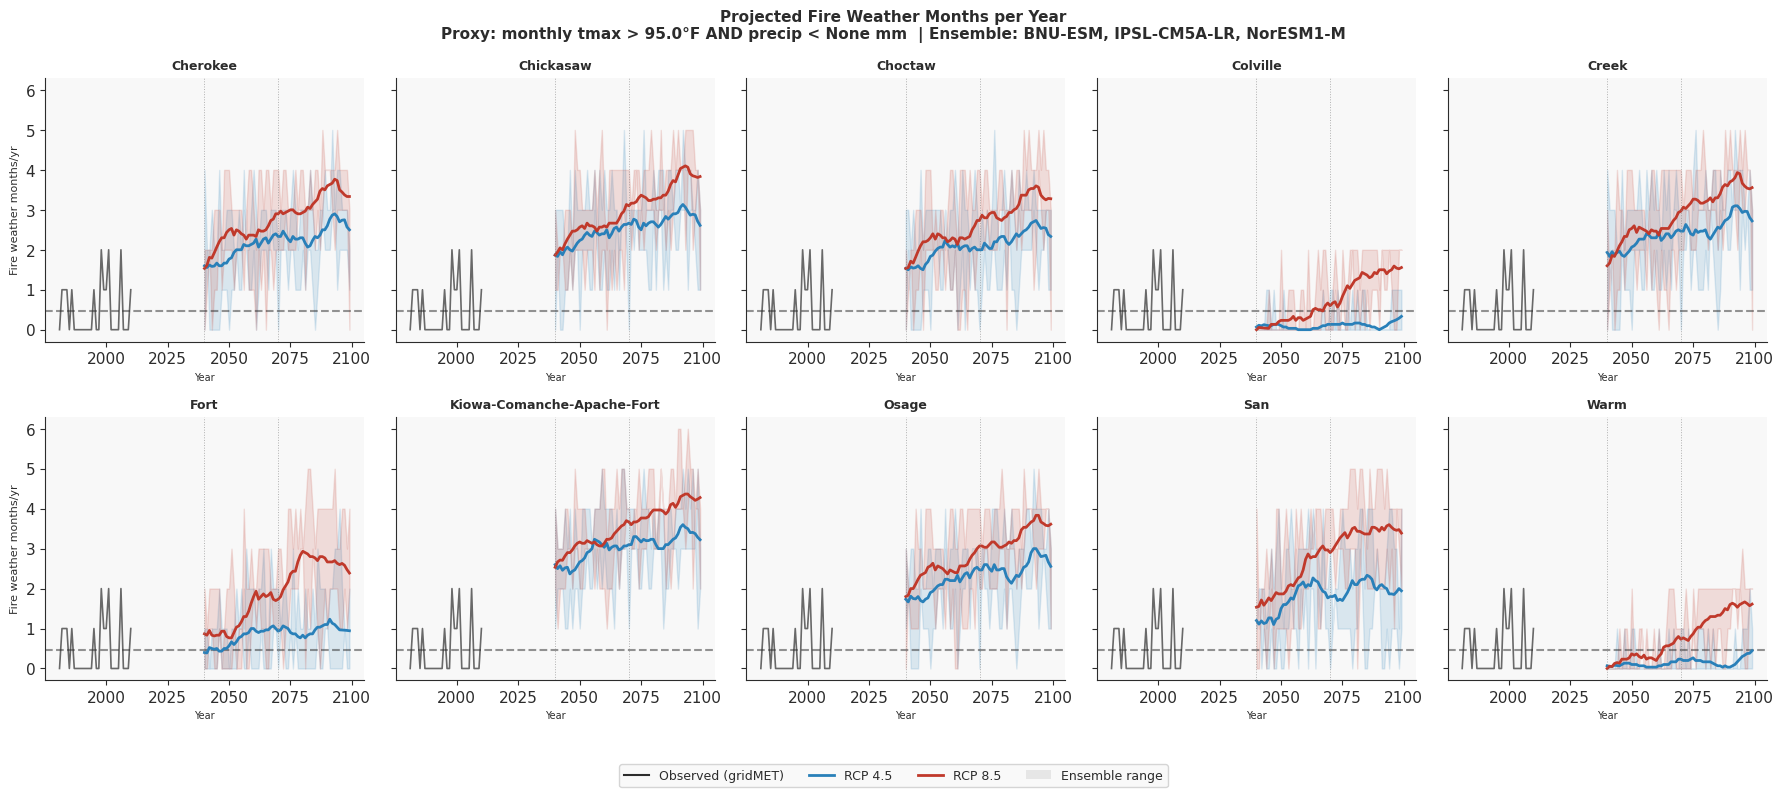

In [12]:
# Time series: RCP 4.5 vs 8.5 divergence 
# Show multi-Tribe ensemble mean trends with scenario uncertainty bands

SCENARIO_COLORS = {
    "rcp45": styles.SKY_BLUE,
    "rcp85": styles.EMBER_RED,
    "historical": styles.CHARCOAL,
}
SCENARIO_LABELS = {
    "rcp45": "RCP 4.5 (moderate mitigation)",
    "rcp85": "RCP 8.5 (business as usual)",
    "historical": "Observed (gridMET)",
}

fig, axes = plt.subplots(
    2, 5, figsize=(18, 8), sharex=False, sharey=True
)
axes = axes.flatten()

for i, name in enumerate(tribal_lands["NAME"]):
    ax = axes[i]

    # Historical observed
    hist_tribe = all_annual[
        (all_annual["NAME"] == name) & (all_annual["source"] == "gridMET")
    ]
    ax.plot(
        hist_tribe["year"], hist_tribe["fw_months"],
        color=SCENARIO_COLORS["historical"], linewidth=1.2,
        alpha=0.7, label="Observed",
    )

    # Historical mean line
    hist_mean = hist_tribe["fw_months"].mean()
    ax.axhline(hist_mean, color=SCENARIO_COLORS["historical"],
               linewidth=1.5, linestyle="--", alpha=0.5)

    # MACAv2 scenarios
    for scenario in ["rcp45", "rcp85"]:
        scen_data = (
            all_annual[
                (all_annual["NAME"] == name) &
                (all_annual["scenario"] == scenario) &
                (all_annual["source"] == "MACAv2")
            ]
            .groupby("year")["fw_months"]
            .agg(["mean", "min", "max"])
            .reset_index()
        )
        if scen_data.empty:
            continue        
        # 10-year rolling mean
        scen_data["smooth"] = scen_data["mean"].rolling(10, center=True, min_periods=1).mean()
        color = SCENARIO_COLORS[scenario]
        ax.fill_between(
            scen_data["year"], scen_data["min"], scen_data["max"],
            color=color, alpha=0.15,
        )
        ax.plot(
            scen_data["year"], scen_data["smooth"],
            color=color, linewidth=2, label=scenario.upper(),
        )

    # Period dividers
    for yr in [MID_START, END_START]:
        ax.axvline(yr, color="gray", linewidth=0.7, linestyle=":", alpha=0.6)

    ax.set_title(name.split()[0], fontsize=9, fontweight="bold")
    ax.set_xlabel("Year", fontsize=7)
    if i % 5 == 0:
        ax.set_ylabel("Fire weather months/yr", fontsize=8)
    sns.despine(ax=ax)

# Shared legend
legend_handles = [
    plt.Line2D([0], [0], color=SCENARIO_COLORS["historical"], lw=1.5, label="Observed (gridMET)"),
    plt.Line2D([0], [0], color=SCENARIO_COLORS["rcp45"],      lw=2,   label="RCP 4.5"),
    plt.Line2D([0], [0], color=SCENARIO_COLORS["rcp85"],      lw=2,   label="RCP 8.5"),
    mpatches.Patch(facecolor="gray", alpha=0.15, label="Ensemble range"),
]
fig.legend(
    handles=legend_handles, loc="lower center",
    ncol=4, fontsize=9, bbox_to_anchor=(0.5, 0),
)
plt.suptitle(
    "Projected Fire Weather Months per Year\n"
    f"Proxy: monthly tmax > {TMAX_THRESHOLD_F}°F AND precip < {PRECIP_THRESHOLD_MM} mm  "
    "| Ensemble: BNU-ESM, IPSL-CM5A-LR, NorESM1-M",
    fontsize=11, fontweight="bold",
)
plt.tight_layout(rect=[0, 0.07, 1, 1])
charts.save_figure(fig, "outputs/figures/climate_projections_time_series.png")
plt.show()

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\climate_projections_change_from_baseline.png


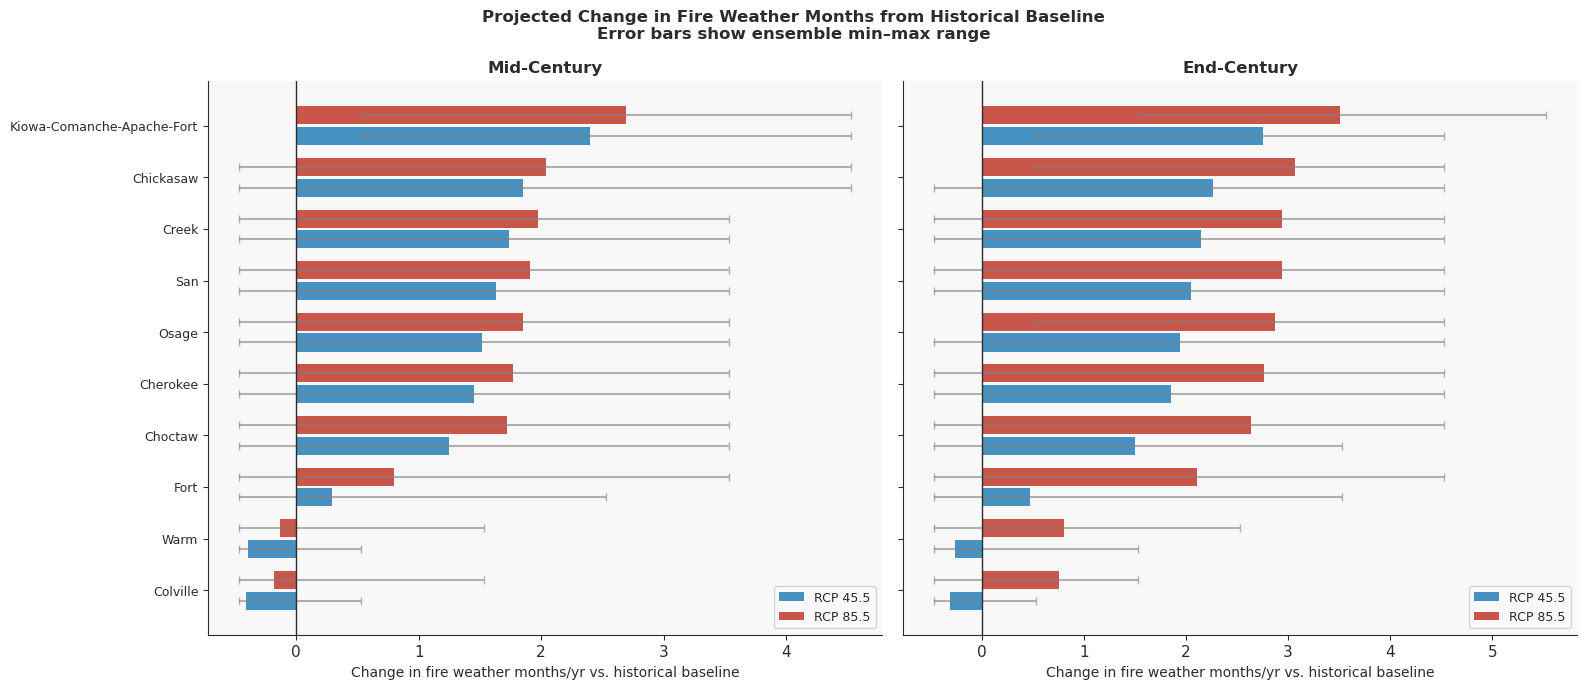

In [13]:
# Change from baseline: ranked bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, period in zip(axes, ["Mid-Century", "End-Century"]):
    for scenario, color, offset in [
        ("rcp45", styles.SKY_BLUE,   -0.2),
        ("rcp85", styles.EMBER_RED,   0.2),
    ]:
        sub = ensemble[
            (ensemble["period"] == period) &
            (ensemble["scenario"] == scenario)
        ].sort_values("delta_from_baseline", ascending=True)

        y = np.arange(len(sub))
        ax.barh(
            y + offset, sub["delta_from_baseline"], 0.35,
            color=color, alpha=0.85,
            xerr=[
                sub["fw_months_mean"] - sub["fw_months_min"],
                sub["fw_months_max"] - sub["fw_months_mean"],
            ],
            capsize=3, ecolor="gray", error_kw={"alpha": 0.6},
            label=f"RCP {scenario[-2:]}.{scenario[-1:]}",
        )

    ax.set_yticks(np.arange(len(sub)))
    ax.set_yticklabels(sub["NAME"].str.split().str[0], fontsize=9)
    ax.axvline(0, color=styles.CHARCOAL, linewidth=1)
    ax.set_xlabel("Change in fire weather months/yr vs. historical baseline", fontsize=10)
    ax.set_title(period, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.suptitle(
    "Projected Change in Fire Weather Months from Historical Baseline\n"
    "Error bars show ensemble min–max range",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
charts.save_figure(fig, "outputs/figures/climate_projections_change_from_baseline.png")
plt.show()

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\climate_projections_rcp_divergence.png


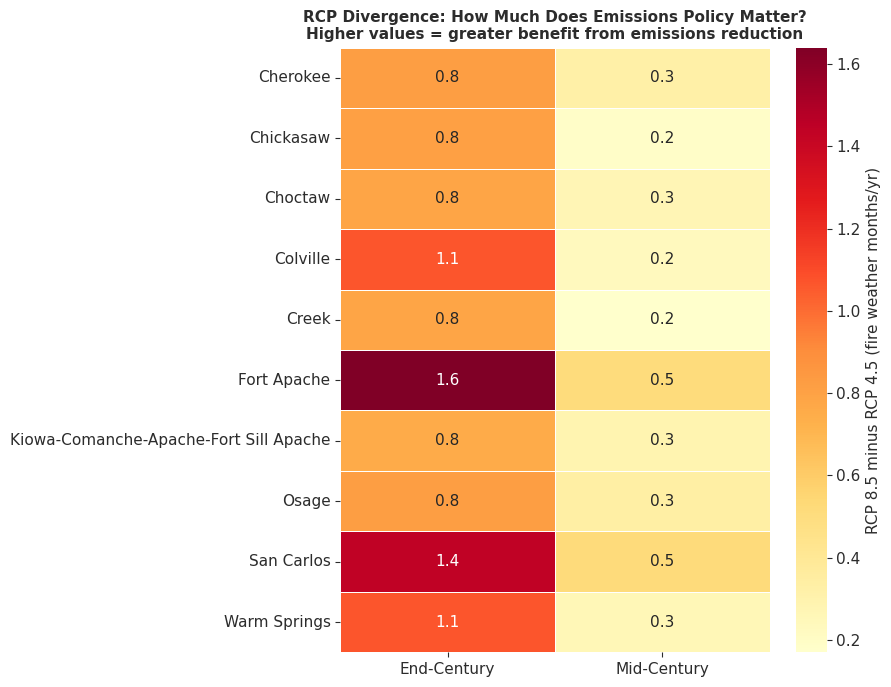

In [14]:
# RCP divergence heatmap 
# How much does policy choice (RCP 4.5 vs 8.5) matter for each Tribe?

div_records = []
for name in tribal_lands["NAME"]:
    for period in ["Mid-Century", "End-Century"]:
        r45 = ensemble[
            (ensemble["NAME"] == name) &
            (ensemble["period"] == period) &
            (ensemble["scenario"] == "rcp45")
        ]["fw_months_mean"].values
        r85 = ensemble[
            (ensemble["NAME"] == name) &
            (ensemble["period"] == period) &
            (ensemble["scenario"] == "rcp85")
        ]["fw_months_mean"].values
        if len(r45) and len(r85):
            div_records.append({
                "NAME":       name,
                "period":     period,
                "divergence": round(float(r85[0]) - float(r45[0]), 2),
            })

div_df    = pd.DataFrame(div_records)
div_pivot = div_df.pivot(index="NAME", columns="period", values="divergence")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    div_pivot,
    annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "RCP 8.5 minus RCP 4.5 (fire weather months/yr)"},
)
ax.set_title(
    "RCP Divergence: How Much Does Emissions Policy Matter?\n"
    "Higher values = greater benefit from emissions reduction",
    fontsize=11, fontweight="bold",
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
charts.save_figure(fig, "outputs/figures/climate_projections_rcp_divergence.png")
plt.show()

Figure saved C:\Users\gekek\Documents\tfs_refactor\outputs\figures\climate_projections_drivers.png


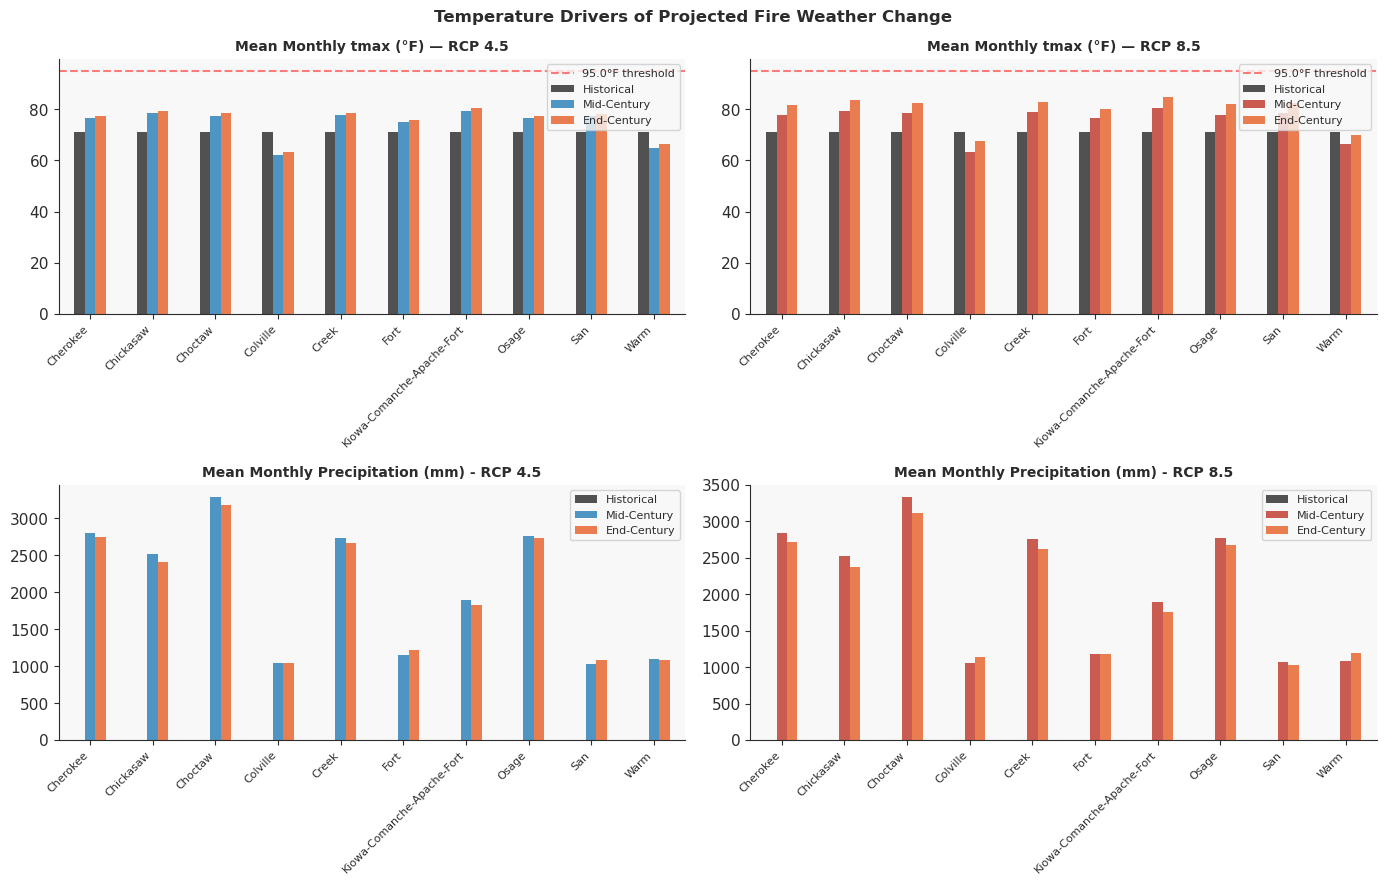

In [15]:
# Temperature and precipitation trends 
# Show the raw drivers behind the fire weather proxy change

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

def _period_means(df, variable, scenario):
    """Compute period mean across all Tribes for one scenario."""
    subset = df[df["scenario"] == scenario] if scenario != "historical" else df
    return (
        subset
        .groupby(["NAME", "period"])[variable]
        .mean().reset_index()
    )

# Combine for plotting
all_monthly = pd.concat([hist_df, proj_df.rename(columns={
    col: col for col in proj_df.columns
})], ignore_index=True)
all_monthly["period"] = all_monthly.apply(
    lambda r: "Historical" if r.get("source") == "gridMET"
    else "Mid-Century" if r["year"] <= MID_END else "End-Century",
    axis=1,
)

for ax, (scenario, label, color) in zip(
    [axes[0, 0], axes[0, 1]],
    [("rcp45", "RCP 4.5", styles.SKY_BLUE),
     ("rcp85", "RCP 8.5", styles.EMBER_RED)],
):
    sub = all_monthly[
        (all_monthly["scenario"].isin([scenario, "historical"])) |
        (all_monthly["source"] == "gridMET")
    ].groupby(["NAME", "period"])["tmax_f"].mean().reset_index()
    pivot = sub.pivot(index="NAME", columns="period", values="tmax_f")
    pivot[["Historical", "Mid-Century", "End-Century"]].plot(
        kind="bar", ax=ax,
        color=[styles.CHARCOAL, color, styles.FIRE_ORANGE],
        alpha=0.82,
    )
    ax.set_title(f"Mean Monthly tmax (°F) — {label}", fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels([n.split()[0] for n in pivot.index], rotation=45, ha="right", fontsize=8)
    ax.axhline(TMAX_THRESHOLD_F, color="red", linestyle="--", alpha=0.5,
               label=f"{TMAX_THRESHOLD_F}°F threshold")
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

for ax, (scenario, label, color) in zip(
    [axes[1, 0], axes[1, 1]],
    [("rcp45", "RCP 4.5", styles.SKY_BLUE),
     ("rcp85", "RCP 8.5", styles.EMBER_RED)],
):
    sub = all_monthly[
        (all_monthly["scenario"].isin([scenario, "historical"])) |
        (all_monthly["source"] == "gridMET")
    ].groupby(["NAME", "period"])["precip_mm"].mean().reset_index()
    pivot = sub.pivot(index="NAME", columns="period", values="precip_mm")
    pivot[["Historical", "Mid-Century", "End-Century"]].plot(
        kind="bar", ax=ax,
        color=[styles.CHARCOAL, color, styles.FIRE_ORANGE],
        alpha=0.82,
    )
    ax.set_title(f"Mean Monthly Precipitation (mm) - {label}", fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels([n.split()[0] for n in pivot.index], rotation=45, ha="right", fontsize=8)
    if PRECIP_THRESHOLD_MM is not None:
        ax.axhline(PRECIP_THRESHOLD_MM, color="blue", linestyle="--", alpha=0.5,
               label=f"{PRECIP_THRESHOLD_MM} mm threshold")  
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle(
    "Temperature Drivers of Projected Fire Weather Change",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
charts.save_figure(fig, "outputs/figures/climate_projections_drivers.png")
plt.show()

## Exports

In [16]:
# Tabular exports
print(f"Analysis run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

ensemble.to_csv(
    constants.OUTPUTS_DIR / "climate_projections_ensemble_summary.csv", index=False
)
print("Exported to outputs/climate_projections_ensemble_summary.csv")

div_df.to_csv(
    constants.OUTPUTS_DIR / "climate_projections_rcp_divergence.csv", index=False
)
print("Exported to outputs/climate_projections_rcp_divergence.csv")

all_annual.to_csv(
    constants.OUTPUTS_DIR / "climate_projections_annual_fw_months.csv", index=False
)
print("Exported to outputs/climate_projections_annual_fw_months.csv")

Analysis run: 2026-04-06 09:42
Exported to outputs/climate_projections_ensemble_summary.csv
Exported to outputs/climate_projections_rcp_divergence.csv
Exported to outputs/climate_projections_annual_fw_months.csv


## Summary and Findings

*(Fill in after running with your results.)*

Questions to address in the narrative:

**What the data shows:**
- Which Tribal Nations face the largest absolute increase in fire weather months under RCP 8.5?
- Where does the RCP 4.5 vs 8.5 divergence grow most sharply after mid-century?
  This is the emissions policy story, the divergence shows what is at stake.
- Is the change driven primarily by temperature increase, precipitation decrease, or both?
  (These have different adaptation implications.)

**Connection to the rest of the series:**
- Cross-reference with `fast_fire_days_analysis.ipynb` historical results: do the same
  Tribes that already have the most fast-fire days also face the largest projected increases?
  If so, that compounding story is important for prioritization.
- Cross-reference with `tribal_fire_capacity_analysis.ipynb`. Do the Tribes projected
  to face the largest increases also have the lowest current fire response capacity?
  That gap is a critical planning finding.

**Limitations:**
- Three-model ensemble is lightweight, a full 20-model ensemble would provide
  more robust uncertainty bounds.
- Fire weather proxy (temperature and precipitation only) understates full fast-fire
  risk because it omits wind. The proxy is conservative.
- MACAv2 is monthly resolution; does not capture day-to-day variability or
  extreme event frequency directly.
- Climate projections carry inherent uncertainty; present as ranges, not single
  point estimates.

**For Tribal decision makers:**
This analysis supports multi-decade fire management planning, BIA and federal
funding justification, and Tribal climate adaptation planning. The RCP divergence
chart is particularly useful for policy advocacy — it quantifies what Tribal lands
stand to gain from national emissions reduction policy.

---
## References

In [17]:
print(generate_citations(["census_aiannh", "maca_projections"]))

References/Data Sources
----------------------------------------
- Census TIGER AIANNH. US Census Bureau. https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
- MACAv2-METDATA Downscaled Climate Projections. Northwest Knowledge Network, University of Idaho. http://thredds.northwestknowledge.net:8080/thredds/dodsC/
